LOAD DATASET


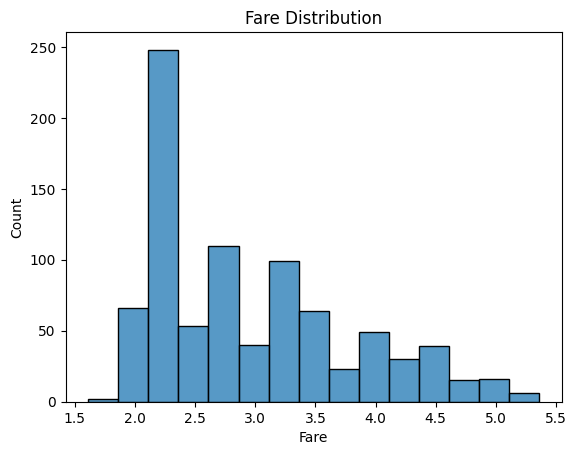

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. load data
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# 2. drop unnecessary columns
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# 3. fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 4. Log Transformation for Fare (to handle outliers and skewness)
df['Fare'] = np.log1p(df['Fare'])

# 5. Remove outliers
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Fare'] > Q1 - 1.5 * IQR) & (df['Fare'] < Q3 + 1.5 * IQR)]



# check distribution
sns.histplot(df['Fare'])
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

# check outliers
# sns.boxplot(df)
# plt.show()

# check skewness
# print(df['Fare'].skew())

# check correlation
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
# plt.show()


